In [18]:
import pandas as pd
df=pd.read_csv('Netflix Dataset.csv')
display(df.head())
print('\n informasi Data')
display(df.info())

,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,07:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",PG-13,123 min,Dramas,A brilliant group of students become card-coun...



 informasi Data
<class 'pandas.DataFrame'>
RangeIndex: 7789 entries, 0 to 7788
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Show_Id       7789 non-null   str  
 1   Category      7789 non-null   str  
 2   Title         7789 non-null   str  
 3   Director      5401 non-null   str  
 4   Cast          7071 non-null   str  
 5   Country       7282 non-null   str  
 6   Release_Date  7779 non-null   str  
 7   Rating        7782 non-null   str  
 8   Duration      7789 non-null   str  
 9   Type          7789 non-null   str  
 10  Description   7789 non-null   str  
dtypes: str(11)
memory usage: 669.5 KB


None

In [ ]:
print("=== JUMLAH DATA BOLONG PER KOLOM ===")
display(disnull().sf.um().sort_values(ascending=False))


=== JUMLAH DATA BOLONG PER KOLOM ===


Director        2388
Cast             718
Country          507
Release_Date      10
Rating             7
Show_Id            0
Category           0
Title              0
Duration           0
Type               0
Description        0
dtype: int64

In [ ]:
df['Director'] = df['Director'].fillna('Tidak Diketahui')
df['Cast'] = df['Cast'].fillna('Tidak Diketahui')
df['Country'] = df['Country'].fillna('Tidak Diketahui')

df = df.dropna(subset=['Release_Date', 'Rating'])

print("=== HASIL X-RAY SETELAH DIBERSIHKAN ===")
display(df.isnull().sum())

=== HASIL X-RAY SETELAH DIBERSIHKAN ===


Show_Id         0
Category        0
Title           0
Director        0
Cast            0
Country         0
Release_Date    0
Rating          0
Duration        0
Type            0
Description     0
dtype: int64

=== TOTAL KONTEN NETFLIX ===
Category
Movie      5379
TV Show    2410
Name: count, dtype: int64




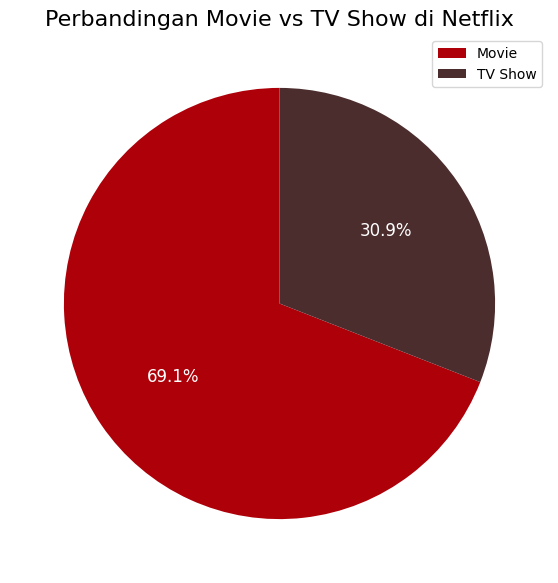

In [26]:
jumlah_kategori = df['Category'].value_counts()

print("=== TOTAL KONTEN NETFLIX ===")
print(jumlah_kategori)
print("\n")

import matplotlib.pyplot as plt

# Menyiapkan kanvas
plt.figure(figsize=(7, 7))
plt.pie(jumlah_kategori, 
        labels=jumlah_kategori.index, 
        autopct='%1.1f%%',
        startangle=90, 
        colors=["#AE0009", "#4C2D2D"], 
        textprops={'color': 'white', 'fontsize': 12})

plt.title('Perbandingan Movie vs TV Show di Netflix', fontsize=16)
plt.legend() 
plt.show()

=== TOP 10 NEGARA PENYUMBANG KONTEN ===
Country
United States     2556
India              923
United Kingdom     397
Japan              226
South Korea        183
Canada             177
Spain              134
France             115
Egypt              101
Mexico             100
Name: count, dtype: int64




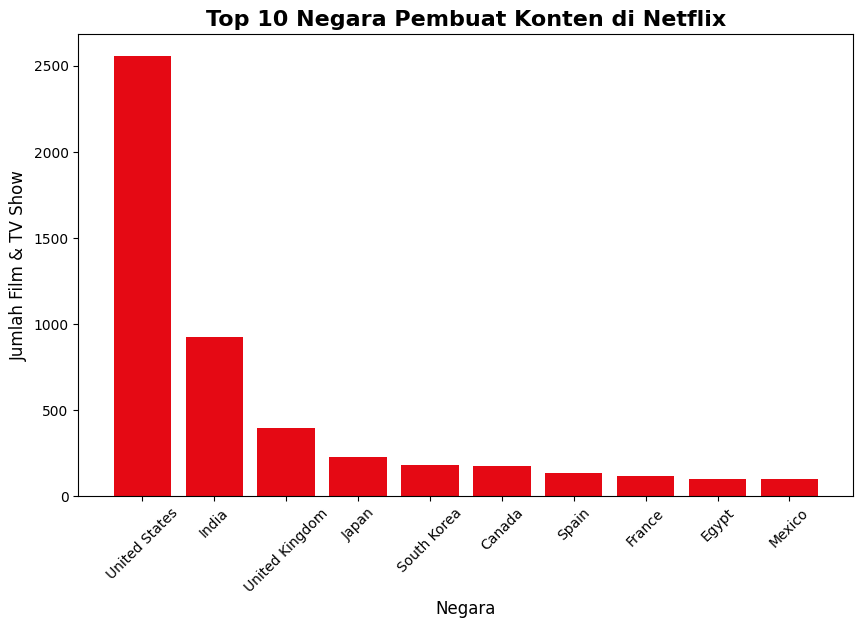

In [25]:
df_negara = df[df['Country'] != 'Tidak Diketahui']

top_negara = df_negara['Country'].value_counts().head(10)

print("=== TOP 10 NEGARA PENYUMBANG KONTEN ===")
print(top_negara)
print("\n")

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(top_negara.index, top_negara.values, color='#E50914')

plt.title('Top 10 Negara Pembuat Konten di Netflix', fontsize=16, fontweight='bold')
plt.xlabel('Negara', fontsize=12)
plt.ylabel('Jumlah Film & TV Show', fontsize=12)

plt.xticks(rotation=45) 
plt.show()

=== DATA TREN RILIS TAHUNAN (2010+) ===
Tahun_Rilis
2010.0       1
2011.0      13
2012.0       3
2013.0      11
2014.0      25
2015.0      88
2016.0     443
2017.0    1225
2018.0    1685
2019.0    2154
2020.0    2010
2021.0     117
Name: count, dtype: int64




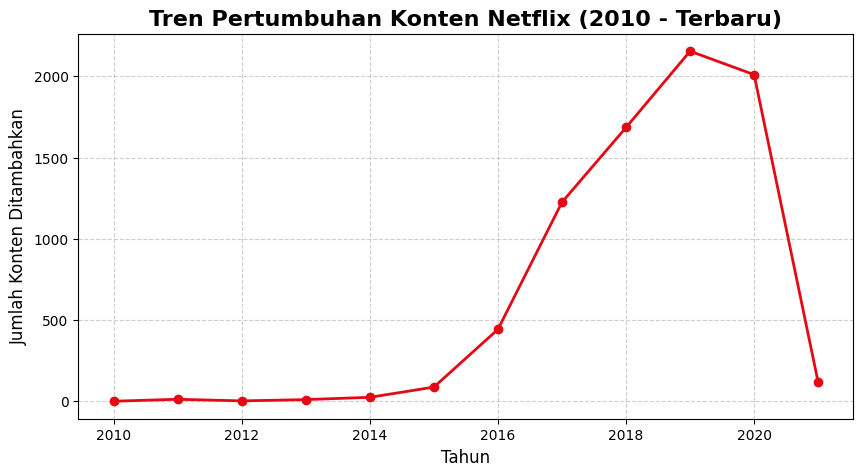

In [24]:
df['Tanggal_Resmi'] = pd.to_datetime(df['Release_Date'].str.strip(), errors='coerce')

df['Tahun_Rilis'] = df['Tanggal_Resmi'].dt.year

tren_tahunan = df['Tahun_Rilis'].value_counts().sort_index()

tren_modern = tren_tahunan[tren_tahunan.index >= 2010]

print("=== DATA TREN RILIS TAHUNAN (2010+) ===")
print(tren_modern)
print("\n")

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(tren_modern.index, tren_modern.values, color='#E50914', marker='o', linewidth=2)
plt.title('Tren Pertumbuhan Konten Netflix (2010 - Terbaru)', fontsize=16, fontweight='bold')
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('Jumlah Konten Ditambahkan', fontsize=12)


plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

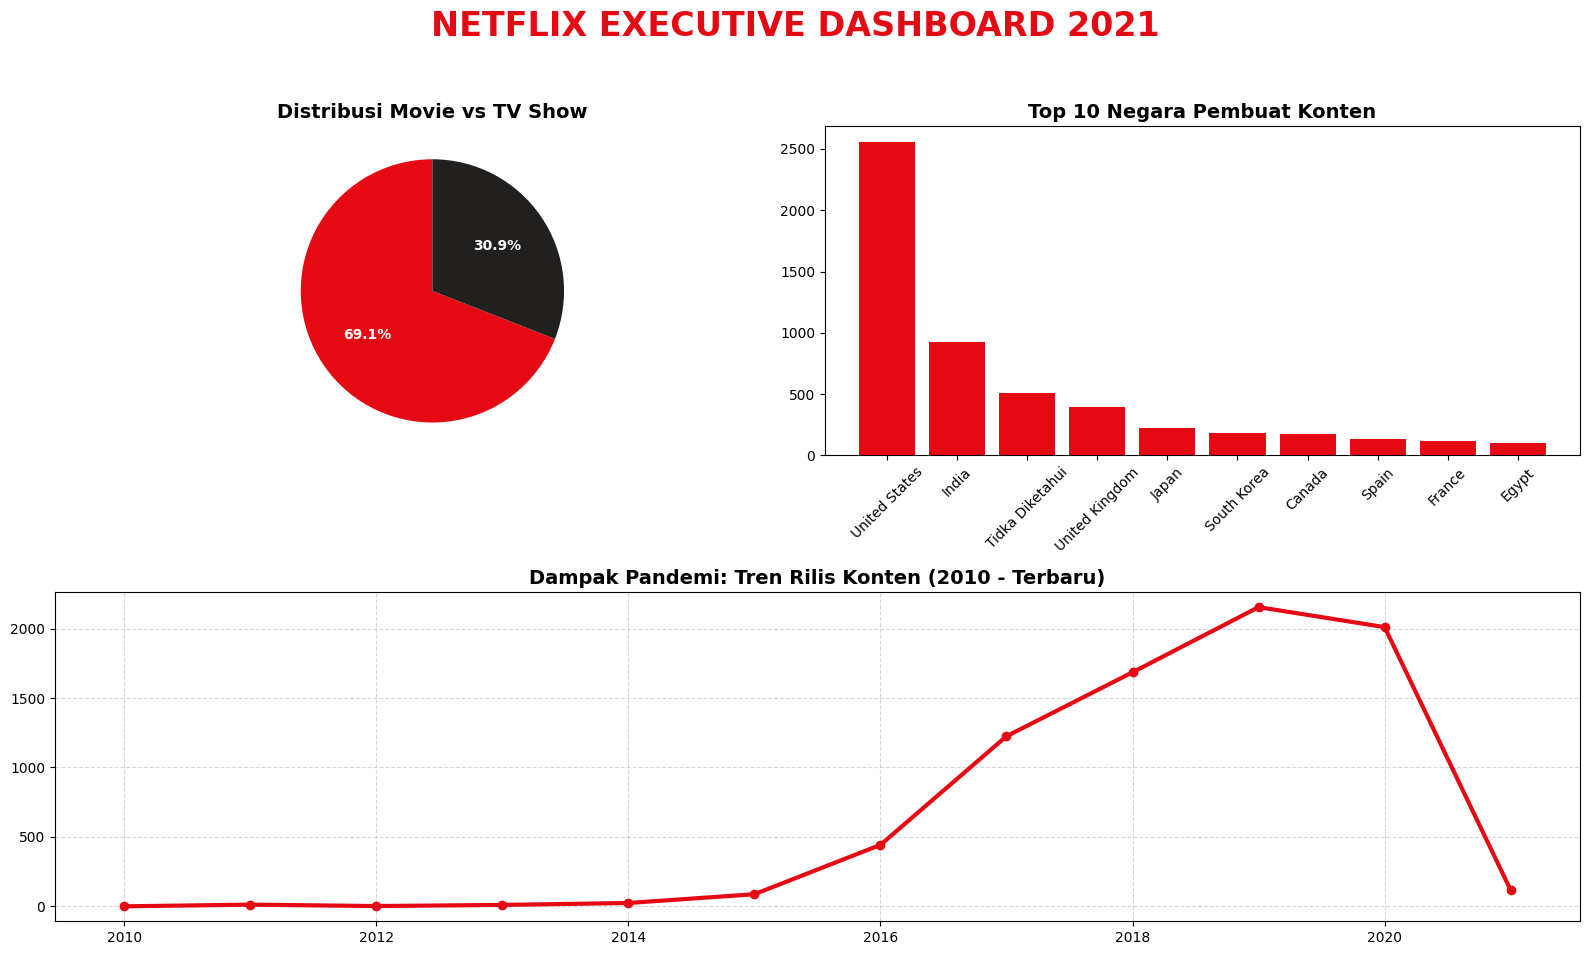

In [23]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('NETFLIX EXECUTIVE DASHBOARD 2021', fontsize=24, fontweight='bold', color='#E50914')


axs[0, 0].pie(jumlah_kategori, labels=jumlah_kategori.index, autopct='%1.1f%%', 
              startangle=90, colors=['#E50914', '#221F1F'], textprops={'color': 'white', 'fontweight': 'bold'})
axs[0, 0].set_title('Distribusi Movie vs TV Show', fontsize=14, fontweight='bold')


axs[0, 1].bar(top_negara.index, top_negara.values, color='#E50914')
axs[0, 1].set_title('Top 10 Negara Pembuat Konten', fontsize=14, fontweight='bold')
axs[0, 1].tick_params(axis='x', rotation=45) 

axs[1, 0].remove() 
axs[1, 1].remove() 
ax_bottom = fig.add_subplot(2, 1, 2) 

ax_bottom.plot(tren_modern.index, tren_modern.values, color='#E50914', marker='o', linewidth=3)
ax_bottom.set_title('Dampak Pandemi: Tren Rilis Konten (2010 - Terbaru)', fontsize=14, fontweight='bold')
ax_bottom.grid(True, linestyle='--', alpha=0.5)


plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])


plt.savefig('Dashboard_Netflix_Jois.png', dpi=300, bbox_inches='tight')


plt.show()